# Exploitation

This section demonstrates Bayesian optimization (BO) with exploitation as the acquisition function. Specifically, the auxiliary optimization problem can be written as:

$$
    \min_{\mathbf{x} \in \Omega} \hat{f}(\mathbf{x}),
$$

where $\hat{f}(\mathbf{x})$ is the surrogate model prediction (acquisition function). Based on the above formulation, the next infill point is obtained by minimizing the model prediction. This is a pure exploitation strategy as it only focuses on minimizing the surrogate model prediction and does not consider unexplored regions of the design space. This can lead to faster convergence to a local optimum, but it may also get stuck in local optima and fail to find the global optimum.

Below code imports required packages and defines modified branin function:

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyDOE3 import lhs
from scimlstudio.models import SingleOutputGP
from scimlstudio.utils import Standardize, Normalize
from gpytorch.mlls import ExactMarginalLogLikelihood

from pymoo.core.problem import Problem
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.optimize import minimize
from pymoo.config import Config
Config.warnings['not_compiled'] = False

# Defining the device and data types
args = {
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    "dtype": torch.float64
}

def modified_branin(x: np.ndarray) -> np.ndarray:
    """
        Function for computing modified branin function value at given input points
    """

    x = np.atleast_2d(x)

    x1 = x[:,0]
    x2 = x[:,1]

    a = 1.
    b = 5.1 / (4.*np.pi**2)
    c = 5. / np.pi
    r = 6.
    s = 10.
    t = 1. / (8.*np.pi)

    y = a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1-t)*np.cos(x1) + s + 5*x1

    return np.expand_dims(y,-1)

lb = np.array([-5., 0.])
ub = np.array([10., 15.])

/home/pkoratik/miniconda3/envs/sm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Below code block defines a pymoo class for auxiliary optimization. This class must inherit from pymoo's `Problem` class and must implement the `__init__` and `_evaluate` method. The init method initializes the problem, stores the surrogate model for future computation, and can perform many other computations. The `_evaluate` method is used to evaluate the acquisition function at given input points. This method is called many during optimization for computing acqusition function value. Note that `_evaluate` method does not return the objective values. Instead, the values are stored in `out` dictionary.

Below code block also initializes the `differential evolution` class. Primarily, there are three important arguments. First is the `pop_size` which determines the number of candidates in a generation. It is set to 15 times the number of dimensions. The second argument controls the mutation factor (F) which controls the amount of mutation to be added to each candidate. The last argument is the cross-over rate (CR) that dictates the probability that a candidate will undergo a mutation. The performance of the DE method is dependent on the value of F and CR.

In [2]:
class Exploitation(Problem):

    def __init__(self, gp, lb: np.ndarray, ub: np.ndarray):
        """
            Class for defining auxiliary optimization problem that uses
            exploitation as the acquisition function
        """

        # initialize parent class
        super().__init__(n_var=lb.shape[0], n_obj=1, n_constr=0, xl=lb, xu=ub)

        self.gp = gp # store the surrogate model

    def _evaluate(self, x, out, *args, **kwargs):

        # convert to torch tensor
        x = torch.from_numpy(x).to(self.gp.x_train)

        # get mean prediction
        y_mean, _ = self.gp.predict(x)

        # store the objective value as numpy array
        out["F"] = y_mean.numpy(force=True)

# Optimization algorithm
algorithm = DE(pop_size=15*lb.shape[0], F=0.9, CR=0.8, seed=1)

## BO loop

Below code implements BO loop with exploitation-based acquisition function. Four initial samples are used with a maximum function evaluation budget of 12. This implies that there will be 8 iterations of the loop. The initial samples are generated using latin hypercube sampling. A Gaussian process (GP) model is used to approximate modified Branin function. The mean prediction of GP model is used as the acquisition function, i.e., $\hat{f}(\mathbf{x}) = \mu(\mathbf{x})$, where $\mu$ is mean GP prediction.

In [3]:
# variables
num_init = 4
max_evals = 24
num_evals = 0

# initial training data
x_train = lhs(lb.shape[0], samples=num_init, criterion='cm', iterations=100, seed=1)
x_train = lb + (ub - lb) * x_train
y_train = modified_branin(x_train)

# increment evals
num_evals += num_init

idx_best = np.argmin(y_train)
fbest = [y_train[idx_best]]
xbest = [x_train[idx_best]]

print("Current best before loop:")
print("x: {}".format(xbest[-1]))
print("f: {}".format(fbest[-1]))

print("\nExploitation Loop:")

# loop
while num_evals < max_evals:

    print(f"\nIteration: {num_evals-num_init+1}")

    # GP
    gp = SingleOutputGP(
        x_train=torch.from_numpy(x_train).to(**args),
        y_train=torch.from_numpy(y_train).to(**args),
        output_transform=Standardize,
        input_transform=Normalize,
    )

    mll = ExactMarginalLogLikelihood(gp.likelihood, gp) # marginal log likelihood

    optimizer = torch.optim.Adam(gp.parameters(), lr=0.01) # optimizer

    # Training the model
    gp.fit(training_iterations=1000, mll=mll, optimizer=optimizer)

    # Find the minimum of surrogate model
    result = minimize(Exploitation(gp, lb, ub), algorithm, verbose=False)

    # Computing true function value at infill point
    y_infill = modified_branin(result.X)

    print("New point (curret opt of surroage model):")
    print("x: {}".format(result.X))
    print("f: {}".format(y_infill.item()))

    # Appending the the new point to the current data set
    x_train = np.vstack(( x_train, result.X.reshape(1,-1) ))
    y_train = np.vstack((y_train, y_infill))

    # increment evals
    num_evals += 1

    # Find current best point
    idx_best = np.argmin(y_train)
    fbest.append(y_train[idx_best])
    xbest.append(x_train[idx_best])
    
    print("Current best:")
    print("x: {}".format(xbest[-1]))
    print("f: {}".format(fbest[-1]))

fbest = np.array(fbest)
xbest = np.array(xbest)

Current best before loop:
x: [-3.125  5.625]
f: [28.46841701]

Exploitation Loop:

Iteration: 1
New point (curret opt of surroage model):
x: [-0.69594577  3.51955028]
f: 27.216643897355404
Current best:
x: [-0.69594577  3.51955028]
f: [27.2166439]

Iteration: 2
New point (curret opt of surroage model):
x: [-5.          4.65395225]
f: 144.81006310150175
Current best:
x: [-0.69594577  3.51955028]
f: [27.2166439]

Iteration: 3
New point (curret opt of surroage model):
x: [-2.94204392  5.65738303]
f: 23.617088105919947
Current best:
x: [-2.94204392  5.65738303]
f: [23.61708811]

Iteration: 4
New point (curret opt of surroage model):
x: [-2.43656027  5.25136856]
f: 19.593984491453593
Current best:
x: [-2.43656027  5.25136856]
f: [19.59398449]

Iteration: 5
New point (curret opt of surroage model):
x: [-2.52358172  6.22847951]
f: 10.813989195567094
Current best:
x: [-2.52358172  6.22847951]
f: [10.8139892]

Iteration: 6
New point (curret opt of surroage model):
x: [-2.21819653  8.41978693]
f

/home/pkoratik/miniconda3/envs/sm/lib/python3.12/site-packages/gpytorch/distributions/multivariate_normal.py:376: NumericalWarning: Negative variance values detected. This is likely due to numerical instabilities. Rounding negative variances up to 1e-10.
  warnings.warn(


New point (curret opt of surroage model):
x: [-3.6799564  13.60011566]
f: -16.643626442491144
Current best:
x: [-3.6799564  13.60011566]
f: [-16.64362644]

Iteration: 13
New point (curret opt of surroage model):
x: [-3.6826081  13.60511315]
f: -16.643776349487887
Current best:
x: [-3.6826081  13.60511315]
f: [-16.64377635]

Iteration: 14
New point (curret opt of surroage model):
x: [-3.68462933 13.61375545]
f: -16.64391338927158
Current best:
x: [-3.68462933 13.61375545]
f: [-16.64391339]

Iteration: 15
New point (curret opt of surroage model):
x: [-3.68793787 13.62565593]
f: -16.644013311642965
Current best:
x: [-3.68793787 13.62565593]
f: [-16.64401331]

Iteration: 16
New point (curret opt of surroage model):
x: [-3.68895198 13.62887471]
f: -16.64402104532935
Current best:
x: [-3.68895198 13.62887471]
f: [-16.64402105]

Iteration: 17
New point (curret opt of surroage model):
x: [-3.68910751 13.62944048]
f: -16.6440214323125
Current best:
x: [-3.68910751 13.62944048]
f: [-16.64402143]

Below code plots the evolution of optimum point with respect to number of iterations:

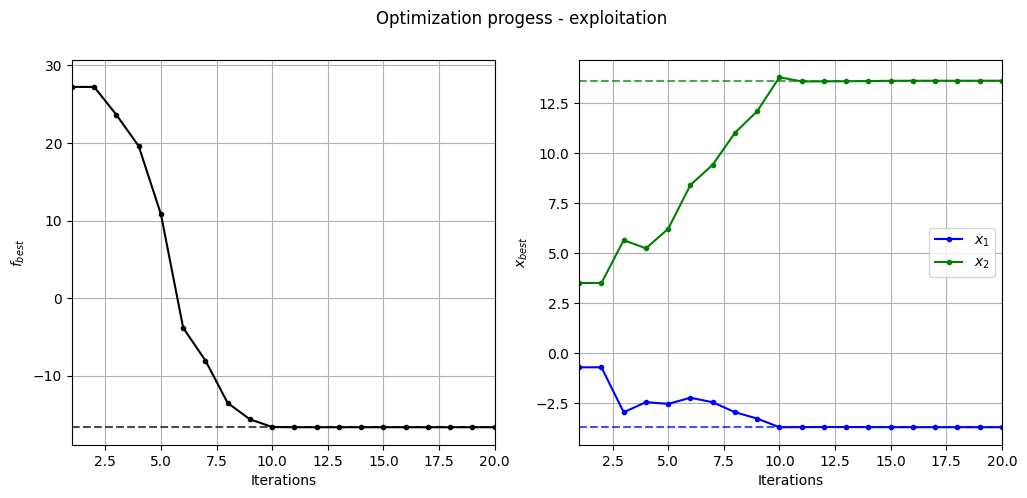

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(fbest, ".k-")
ax[0].set_xlabel("Iterations")
ax[0].set_ylabel("$f_{best}$")
ax[0].axhline(y=-16.64, c="k", linestyle="--", alpha=0.7)
ax[0].set_xlim(left=1, right=fbest.shape[0]-1)
ax[0].grid()

ax[1].plot(xbest[:,0], ".b-", label="$x_1$")
ax[1].plot(xbest[:,1], ".g-", label="$x_2$")
ax[1].axhline(y=-3.689, c="b", linestyle="--", alpha=0.7)
ax[1].axhline(y=13.630, c="g", linestyle="--", alpha=0.7)
ax[1].set_xlim(left=1, right=xbest.shape[0]-1)
ax[1].set_ylabel("$x_{best}$")
ax[1].set_xlabel("Iterations")
ax[1].legend()
ax[1].grid()

_ = plt.suptitle("Optimization progess - exploitation")

Below code plots the infill points added during the optimization process:

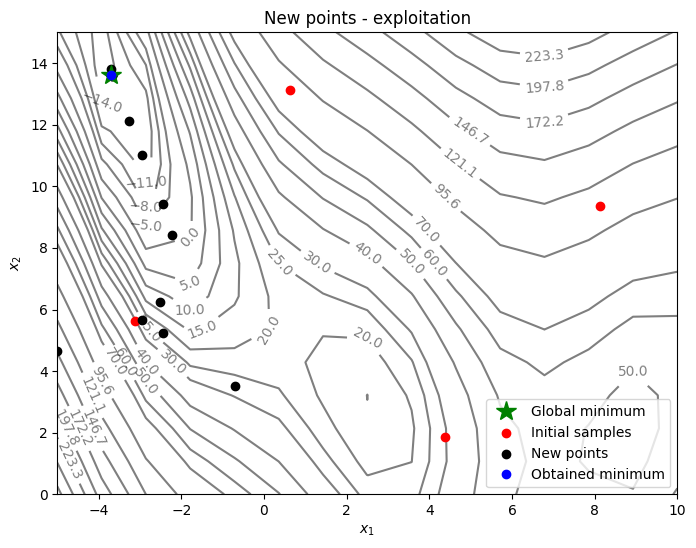

In [5]:
num_pts_per_dim = 15
x1 = np.linspace(lb[0], ub[0], num_pts_per_dim)
x2 = np.linspace(lb[1], ub[1], num_pts_per_dim)
X1, X2 = np.meshgrid(x1, x2)

x = np.hstack(( X1.reshape(-1,1), X2.reshape(-1,1) ))

Z = modified_branin(x).reshape(num_pts_per_dim, num_pts_per_dim)

# Level
levels = np.linspace(-17, -5, 5)
levels = np.concatenate((levels, np.linspace(0, 30, 7)))
levels = np.concatenate((levels, np.linspace(40, 60, 3)))
levels = np.concatenate((levels, np.linspace(70, 300, 10)))

fig, ax = plt.subplots(figsize=(8,6))

# Contours and global opt
CS=ax.contour(X1, X2, Z, levels=levels, colors='k', linestyles='solid', alpha=0.5, zorder=-10)
ax.clabel(CS, inline=1)
ax.plot(-3.689, 13.630, 'g*', markersize=15, label="Global minimum")

# Pointss
ax.scatter(x_train[0:num_init,0], x_train[0:num_init,1], c="red", label='Initial samples')
ax.scatter(x_train[num_init:,0], x_train[num_init:,1], c="black", label='New points')
ax.plot(xbest[-1][0], xbest[-1][1], 'bo', label="Obtained minimum")

# asthetics
ax.legend()
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
_ = ax.set_title("New points - exploitation")

As can be seen in above plots, in each iteration, points are added where the minimum of the surrogate model is. As a result, optimization has a tendency to linger around local optimum which results in a slow convergence rate. So, it is important to balance exploitation and exploration.

> __*NOTE*__: Due to randomness in GP training and differential evolution, results may vary slightly between runs. So, it is recommend to run the code multiple times to see average behavior.